In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/Google_Stock_Price_Train.xlsx - Google_Stock_Price_Train.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,01/03/2012,325.25,332.83,324.97,663.59,"73,80,500"
1,01/04/2012,331.27,333.87,329.08,666.45,"57,49,400"
2,01/05/2012,329.83,330.75,326.89,657.21,"65,90,300"
3,01/06/2012,328.34,328.77,323.68,648.24,"54,05,900"
4,01/09/2012,322.04,322.29,309.46,620.76,"1,16,88,800"


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Extract the 'Open' price column for prediction
df_open = df[['Open']]
df_open = df_open.values # Convert to numpy array

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
df_open_scaled = scaler.fit_transform(df_open)

# Split the data into training and testing sets (75% train, 25% test) - time-based split
train_size = int(len(df_open_scaled) * 0.75)
test_size = len(df_open_scaled) - train_size
train_data = df_open_scaled[0:train_size, :]
test_data = df_open_scaled[train_size:len(df_open_scaled), :]

print(f"Training data size: {len(train_data)}")
print(f"Testing data size: {len(test_data)}")

Training data size: 1131
Testing data size: 378


Now, let's create the time series dataset for the LSTM model. We'll use a `time_step` of 50, meaning each prediction will be based on the previous 50 'Open' prices.

In [ ]:
# Function to create dataset with time steps
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        X.append(a)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

# Reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 50 # As specified by the user
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1080, 50)
y_train shape: (1080,)
X_test shape: (327, 50)
y_test shape: (327,)


In [ ]:
# Reshape input to be [samples, time_steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Reshaped X_train shape: {X_train.shape}")
print(f"Reshaped X_test shape: {X_test.shape}")

Reshaped X_train shape: (1080, 50, 1)
Reshaped X_test shape: (327, 50, 1)


In [ ]:
# Create the Stacked LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - loss: 0.0280 - val_loss: 0.0572
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0052 - val_loss: 0.0033
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0030 - val_loss: 0.0047
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0024 - val_loss: 0.0090
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0022 - val_loss: 0.0078
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - loss: 0.0019 - val_loss: 0.0077
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.0019 - val_loss: 0.0042
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0018 - val_loss: 0.0076
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0021 - val_loss: 0.0030
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - loss: 0.0019 - val_loss: 0.0033
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4

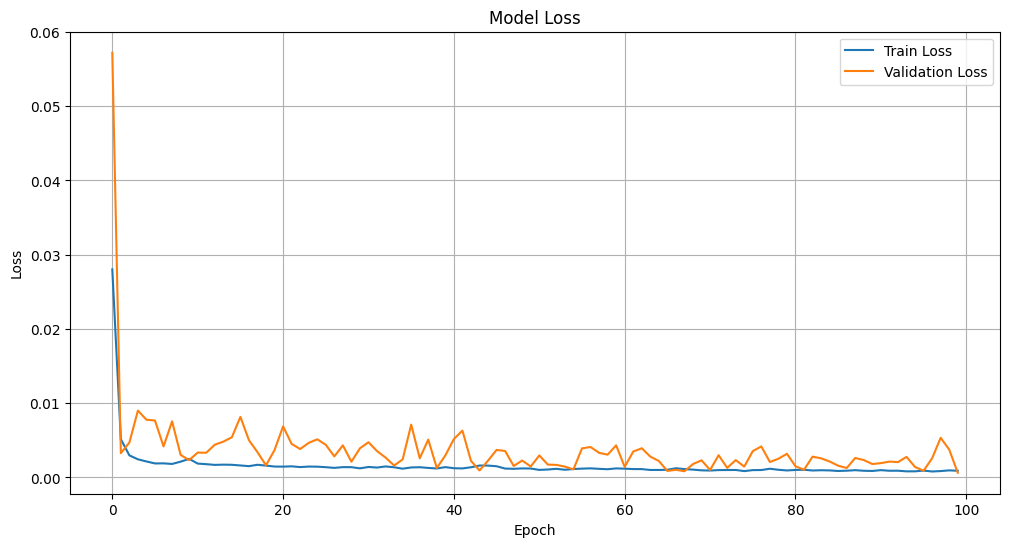

In [ ]:
# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=64, verbose=1)

import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

Now that the model is trained, let's make predictions on the test data and then for the next 15 days. We'll need to inverse transform the scaled predictions back to their original 'Open' price values.

In [ ]:
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform to original scale
train_predict = scaler.inverse_transform(train_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate RMSE (Root Mean Squared Error) for evaluation
import math
from sklearn.metrics import mean_squared_error

print(f"Train RMSE: {math.sqrt(mean_squared_error(y_train_actual, train_predict))}")
print(f"Test RMSE: {math.sqrt(mean_squared_error(y_test_actual, test_predict))}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Train RMSE: 17.667759522367835
Test RMSE: 20.118082031399016


In [ ]:
x_input = test_data[len(test_data) - time_step:].reshape(1, -1)
x_input = x_input.reshape(1, time_step, 1)

future_predictions = []
i = 0
num_future_days = 15 # Predict for the next 15 days

while(i < num_future_days):
    if(len(x_input) > time_step):
        x_input = np.array(x_input[1:])
        print(x_input.shape)
        x_input = x_input.reshape(1, time_step, 1)
        yhat = model.predict(x_input, verbose=0)
        future_predictions.append(yhat[0])
        x_input = np.append(x_input[:,1:,:], [[yhat[0]]], axis=1)
    else:
        yhat = model.predict(x_input, verbose=0)
        future_predictions.append(yhat[0])
        x_input = np.append(x_input[:,1:,:], [[yhat[0]]], axis=1)
    i = i + 1

# Inverse transform the future predictions
future_predictions_actual = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

print("Predicted Opening Prices for the next 15 days:")
for day, price in enumerate(future_predictions_actual):
    print(f"Day {day + 1}: {price[0]:.2f}")

Predicted Opening Prices for the next 15 days:
Day 1: 1040.00
Day 2: 1037.08
Day 3: 1033.51
Day 4: 1029.60
Day 5: 1025.60
Day 6: 1021.69
Day 7: 1017.95
Day 8: 1014.44
Day 9: 1011.15
Day 10: 1008.08
Day 11: 1005.21
Day 12: 1002.52
Day 13: 1000.00
Day 14: 997.63
Day 15: 995.39
